## Salcedo-Puerto et al. (2024) – HTC of Industrial Kraft Lignin

**Paper:** Hydrothermal carbonization of industrial kraft lignin: Assessment of operational parameters  
**DOI:** 10.1016/j.fuel.2024.132389  
**Journal:** Fuel, Volume 373, 132389

### Overview
This notebook ingests experimental data from the Salcedo-Puerto 2024 study on hydrothermal carbonization (HTC) of industrial kraft lignin (IKL). The paper investigates:
- Effect of temperature (200–240°C) on HTC performance
- Effect of residence time (3–24 hours) at 240°C
- Effect of process water recirculation (0–80 vol%)
- Hydrochar composition (C/H/O/N/S), proximate analysis, and heating values
- Mass yields and energy yields

### Notebook Structure
1. **Helper functions and schema**: Data ingestion utilities and canonical column definitions
2. **Data tables**: Table 3 composition data and digitized yields from figures
3. **Data ingestion**: Merge composition data with operational conditions and yields
4. **Visualization**: Plot operational parameter effects (temperature, time, recirculation)
5. **Quality assurance**: Schema validation, QA plots, and envelope checks
6. **Final output**: CSV export for master dataset integration

In [1]:
import pandas as pd, numpy as np, json
from pathlib import Path

COLUMNS = [
    "DOI","Provenance","Ref","Source_Figure",
    "Process_type","Process_subtype",
    "Feedstock","Family","Tier",
    "T","t","IC","Pressure","Solvent_or_medium","Reactor","Separation_method",'atmosphere',"Yield_basis",
    "Catalyst","Catalyst_Biomass_ratio","Heating_rate","Stirring_velocity","Water_Biomass_ratio",
    "Lignin","Cellulose_pct","Hemicellulose_pct","Extractives_pct",
    "C","H","O","N","S","Ash","O/C","H/C","HHV_input",
    "B_Y","C_Y","A_Y","G_Y","GW_Y",
    "E_B","E_H","C_B","C_H",
    "HHV_biooil","C_biooil","H_biooil","O_biooil","N_biooil","S_biooil",
    "HHV_biochar","C_biochar","H_biochar","O_biochar","N_biochar","S_biochar",
    "Moisture_min","Moisture_max",
    "Lignin_Rich","extra"
]
def _empty_row(): return {k: np.nan for k in COLUMNS}

def _family(feed:str)->str:
    s = (feed or "").lower()
    if any(x in s for x in ["straw","corn","rice","wheat","soy","herbaceous","tobacco"]): return "Ag residues / Herbaceous"
    if any(x in s for x in ["spruce","pine","fir"]): return "Woody Biomass / Softwood"
    if "poplar" in s or "eucalyptus" in s: return "Woody Biomass / Hardwood"
    if "mix" in s or "blend" in s: return "Woody Biomass / Mixed"
    return "Lignocellulosic / Other"

def _safe_json_load(obj):
    if isinstance(obj, dict): 
        return obj
    if isinstance(obj, str) and obj.strip():
        try:
            return json.loads(obj)
        except Exception:
            return {}
    return {}

def _btw_to_ic(s):
    """
    Convert biomass:water strings to biomass/water numeric ratio (IC).
    Examples: '1:10' -> 0.1 ; '1/15' -> 0.0667 ; '0.1' -> 0.1
    """
    if s is None: 
        return np.nan
    if isinstance(s, (int, float, np.integer, np.floating)):
        return float(s)
    txt = str(s).strip().replace(",", ".")
    if ':' in txt or '/' in txt:
        for sep in [':','/']:
            if sep in txt:
                a,b = txt.split(sep,1)
                try:
                    a = float(a.strip()); b = float(b.strip())
                    return a/b if b != 0 else np.nan
                except Exception:
                    return np.nan
    try:
        return float(txt)
    except Exception:
        return np.nan

def _oc(C,H,O):
    if pd.isna(C) or C<=0 or pd.isna(O): return np.nan
    return round((O/16.0)/(C/12.01), 3)

def _hc(C,H,O):
    if pd.isna(C) or C<=0 or pd.isna(H): return np.nan
    return round((H/1.008)/(C/12.01), 3)

def _isna(v): return v is None or (isinstance(v,(float,np.floating)) and np.isnan(v))

def _upsert(df, row, keys=("DOI","Feedstock","T","t","Catalyst","Solvent_or_medium","Source_Figure","Ref")):
    if df.empty: 
        return pd.DataFrame([row], columns=row.keys())
    mask = pd.Series(True, index=df.index)
    for k in keys:
        if k not in df.columns:
            df[k] = np.nan
        a = df[k].astype(object).where(~df[k].isna(), "__NA__")
        b = "__NA__" if _isna(row.get(k)) else str(row.get(k))
        mask &= (a.astype(str) == b)
    if mask.any():
        i = mask.idxmax()
        for k,v in row.items():
            if k in df.columns and not _isna(v):
                df.at[i,k] = v
        return df
    return pd.concat([df, pd.DataFrame([row])], ignore_index=True)

def add_feed(df, *, doi, prov, ref, feedstock,
             C=None,H=None,O=None,N=None,S=None,Ash=None, HHV_input=None,
             lignin=None,cell=None,hemi=None,extract=None, moisture=None, source_note="Feed table/text"):
    row = _empty_row()
    row.update(dict(
        DOI=doi, Provenance=prov, Ref=ref, Source_Figure=source_note,
        Process_type="Hydrothermal", Process_subtype=None,
        Feedstock=feedstock, Family=_family(feedstock), Tier="Experimental",
        Pressure=None, Solvent_or_medium=None, Reactor=None, Separation_method=None,
        Yield_basis="wt% of dry feedstock",
        C=C,H=H,O=O,N=N,S=S,Ash=Ash, HHV_input=HHV_input,
        Lignin=lignin, Cellulose_pct=cell, Hemicellulose_pct=hemi, Extractives_pct=extract,
        Moisture_min=moisture, Moisture_max=moisture,
        Lignin_Rich=True,
        extra=json.dumps({"provenance":{"doi":doi,"source":[source_note]}}, ensure_ascii=False)
    ))
    return _upsert(df, row, keys=("DOI","Feedstock","Ref"))

def add_or_patch_run(
    df, *,
    doi, prov, ref, source, feedstock,
    T=None, t_min=None, t_h=None, BTW=None, IC=None,
    catalyst=None, cat_wt_pct=None, solvent="Water", reactor=None, sep=None,
    process_subtype=None, yield_basis="wt% of dry feedstock",
    BY=None, CY=None, AY=None, GY=None, GWY=None,
    HHV_bo=None, C_bo=None, H_bo=None, O_bo=None, N_bo=None, S_bo=None,
    HHV_ch=None, C_ch=None, H_ch=None, O_ch=None, N_ch=None, S_ch=None,
    label=None, notes=None, extra=None, pressure_text=None,
    stirring_rpm=None, heating_rate=None, atmosphere=None 
):
    if t_min is None and t_h is not None: 
        t_min = float(t_h)*60.0
    if IC is None and BTW is not None: 
        IC = _btw_to_ic(BTW)

    row = _empty_row()
    row.update(dict(
        DOI=doi, Provenance=prov, Ref=ref, Source_Figure=source,
        Process_type="Hydrothermal",
        Process_subtype=(process_subtype or ("Catalytic" if catalyst else "Non-catalytic")),
        Feedstock=feedstock, Family=_family(feedstock), Tier="Experimental",
        T=(None if T is None else float(T)),
        t=(None if t_min is None else float(t_min)),
        IC=(None if IC is None else float(IC)),
        Pressure=pressure_text if pressure_text else "autogenic",
        Solvent_or_medium=solvent, Reactor=reactor, Separation_method=sep,
        atmosphere=atmosphere, 
        Yield_basis=yield_basis,
        Catalyst=(None if not catalyst else str(catalyst)),
        Catalyst_Biomass_ratio=(None if cat_wt_pct is None else float(cat_wt_pct)/100.0),
        Water_Biomass_ratio=(None if IC is None else round(1.0/float(IC),3)) if IC not in (None,0) else None,
        Heating_rate=heating_rate,
        Stirring_velocity=stirring_rpm,

        B_Y=None if BY is None else float(BY),
        C_Y=None if CY is None else float(CY),
        A_Y=None if AY is None else float(AY),
        G_Y=None if GY is None else float(GY),
        GW_Y=None if GWY is None else float(GWY),

        HHV_biooil=None if HHV_bo is None else float(HHV_bo),
        C_biooil=None if C_bo is None else float(C_bo),
        H_biooil=None if H_bo is None else float(H_bo),
        O_biooil=None if O_bo is None else float(O_bo),
        N_biooil=None if N_bo is None else float(N_bo),
        S_biooil=None if S_bo is None else float(S_bo),

        HHV_biochar=None if HHV_ch is None else float(HHV_ch),
        C_biochar=None if C_ch is None else float(C_ch),
        H_biochar=None if H_ch is None else float(H_ch),
        O_biochar=None if O_ch is None else float(O_ch),
        N_biochar=None if N_ch is None else float(N_ch),
        S_biochar=None if S_ch is None else float(S_ch),

        Lignin_Rich=True
    ))
    ex = {"label": label, "notes": notes}
    if extra: ex.update(extra)
    row["extra"] = json.dumps({k:v for k,v in ex.items() if v is not None}, ensure_ascii=False)
    return _upsert(df, row)

def _get_ER_pct(r):
    ex = _safe_json_load(r.get("extra"))
    er = ex.get("ER_pct")
    try:
        return float(er) if er is not None else np.nan
    except Exception:
        return np.nan

def finalize(df):
    out = df.copy()

    num_cols = [
        "B_Y","C_Y","A_Y","G_Y","GW_Y",
        "HHV_biooil","C_biooil","H_biooil","O_biooil","N_biooil","S_biooil",
        "HHV_biochar","C_biochar","H_biochar","O_biochar","N_biochar","S_biochar",
        "C","H","O","N","S","Ash","T","t","IC","HHV_input"
    ]
    for c in num_cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    for i,r in out.iterrows():
        BY, CY = r.get("B_Y"), r.get("C_Y")
        HHV_bo, HHV_ch = r.get("HHV_biooil"), r.get("HHV_biochar")
        C_bo = r.get("C_biooil"); C_ch = r.get("C_biochar")

        Cf,Hf,Of = r.get("C"), r.get("H"), r.get("O")
        out.at[i,"O/C"] = _oc(Cf,Hf,Of); out.at[i,"H/C"] = _hc(Cf,Hf,Of)

        BY_ok = pd.notna(BY) and 0 <= BY <= 100
        CY_ok = pd.notna(CY) and 0 <= CY <= 100
        out.at[i,"E_B"] = (BY/100.0)*HHV_bo if BY_ok and pd.notna(HHV_bo) else np.nan
        out.at[i,"E_H"] = (CY/100.0)*HHV_ch if CY_ok and pd.notna(HHV_ch) else np.nan
        out.at[i,"C_B"] = (BY/100.0)*(C_bo/100.0) if BY_ok and pd.notna(C_bo) else np.nan
        out.at[i,"C_H"] = (CY/100.0)*(C_ch/100.0) if CY_ok and pd.notna(C_ch) else np.nan

        parts = [x for x in [BY, CY, r.get("A_Y"), r.get("G_Y")] if pd.notna(x)]
        ex = _safe_json_load(r.get("extra"))
        if parts:
            s = float(np.nansum(parts))
            ex.setdefault("QA", {})["mass_closure_sum_pct"] = round(s,2)
            ex["QA"]["Unassigned_or_over_pct"] = round(100.0 - s, 2)

        elems_bo = [r.get("C_biooil"), r.get("H_biooil"), r.get("O_biooil"), r.get("N_biooil"), r.get("S_biooil")]
        if any(pd.notna(x) for x in elems_bo):
            ex.setdefault("QA", {})["biooil_elem_sum_pct"] = round(float(np.nansum([x for x in elems_bo if pd.notna(x)])), 2)

        elems_ch = [r.get("C_biochar"), r.get("H_biochar"), r.get("O_biochar"), r.get("N_biochar"), r.get("S_biochar")]
        if any(pd.notna(x) for x in elems_ch):
            ex.setdefault("QA", {})["biochar_elem_sum_pct"] = round(float(np.nansum([x for x in elems_ch if pd.notna(x)])), 2)

        out.at[i,"extra"] = json.dumps(ex, ensure_ascii=False)
    return out

def propagate_and_clean(df):
    import math
    out = df.copy()
    feed_keys = ["C","H","O","N","S","Ash","HHV_input","Cellulose_pct","Hemicellulose_pct","Lignin","Extractives_pct"]
    feed_map = {}
    for feed, g in out.groupby("Feedstock", dropna=False):
        g1 = g[g["Source_Figure"].fillna("").str.contains("feed", case=False)]
        pick = g1.iloc[0] if not g1.empty else (g[(g["C"].notna()) & (g["H"].notna()) & (g["O"].notna())].iloc[0] if not g.empty else None)
        if pick is not None:
            feed_map[feed] = {k: pick.get(k, np.nan) for k in feed_keys}
    for idx, r in out.iterrows():
        feed = r.get("Feedstock")
        if feed in feed_map:
            for k,v in feed_map[feed].items():
                if k in out.columns and (pd.isna(out.at[idx,k]) or (isinstance(out.at[idx,k], float) and math.isnan(out.at[idx,k]))):
                    out.at[idx,k] = v
    out["O/C"] = [_oc(c,h,o) for c,h,o in zip(out.get("C"), out.get("H"), out.get("O"))]
    out["H/C"] = [_hc(c,h,o) for c,h,o in zip(out.get("C"), out.get("H"), out.get("O"))]
    out_cols = ["B_Y","C_Y","A_Y","G_Y","HHV_biooil","C_biooil","HHV_biochar","C_biochar"]
    for c in out_cols:
        if c not in out.columns:
            out[c] = np.nan
    has_out = out[out_cols].notna().any(axis=1)
    return out.loc[has_out].copy()

def propagate_feed_chem(df):
    out = df.copy()
    chem = ["C","H","O","N","S","Ash","HHV_input","Cellulose_pct","Hemicellulose_pct","Lignin","Extractives_pct"]
    feed_rows = {}
    for feed, g in out.groupby("Feedstock", dropna=False):
        gfeed = g[g["Source_Figure"].fillna("").str.contains("feed", case=False)]
        pick = gfeed.iloc[0] if not gfeed.empty else (g[(g["C"].notna()) & (g["H"].notna()) & (g["O"].notna())].iloc[0] if not g.empty else None)
        if pick is not None: feed_rows[feed] = pick
    for i,r in out.iterrows():
        pick = feed_rows.get(r.get("Feedstock"))
        if pick is None: continue
        for k in chem:
            if pd.isna(out.at[i,k]): out.at[i,k] = pick.get(k)
    out["O/C"] = [_oc(c,h,o) for c,h,o in zip(out.get("C"), out.get("H"), out.get("O"))]
    out["H/C"] = [_hc(c,h,o) for c,h,o in zip(out.get("C"), out.get("H"), out.get("O"))]
    return out

def attach_biochar_props(df, records):
    """
    records: iterable of dicts with keys:
      feedstock, T, t, HHV_biochar, C_biochar, [ref, source]
    """
    out = df.copy()
    for rec in records:
        m = (out["Feedstock"].astype(str)==str(rec["feedstock"])) & (out["T"]==float(rec["T"])) & (out["t"]==float(rec["t"]))
        idx = list(out[m].index)
        for i in idx:
            out.at[i,"HHV_biochar"] = rec.get("HHV_biochar", out.at[i,"HHV_biochar"])
            out.at[i,"C_biochar"] = rec.get("C_biochar", out.at[i,"C_biochar"])
            ex = _safe_json_load(out.at[i,"extra"])
            ex.setdefault("provenance_updates", []).append({k:rec[k] for k in ["ref","source"] if k in rec})
            out.at[i,"extra"] = json.dumps(ex, ensure_ascii=False)
    return finalize(out)

df = pd.DataFrame(columns=COLUMNS)

In [2]:
SALCEDO_2024_DOI = "10.1016/j.fuel.2024.132389"
prov_tbl3 = "Proximate & ultimate (Table 3, O is daf); HHV from text when given."

TABLE3_SALCEDO2024 = {
    "IKL": {
        "DOI": SALCEDO_2024_DOI, "prov": prov_tbl3,
        "C_biochar": 63.97, "H_biochar": 6.14, "N_biochar": 0.17, "S_biochar": 2.17, "O_biochar": 26.40,
        "Ash_biochar": 1.17, "VM": 70.9, "FC": 27.9, "FR": 0.39,
        "HHV_biochar": 26.98,
        "HHV_biooil": None, "C_biooil": None, "H_biooil": None, "O_biooil": None, "N_biooil": None, "S_biooil": None,
        "map_T": None, "map_t_min": None, "map_recirc_volpct": None
    },
    "HTC-200-6": {
        "DOI": SALCEDO_2024_DOI, "prov": prov_tbl3,
        "C_biochar": 65.70, "H_biochar": 5.98, "N_biochar": 0.16, "S_biochar": 2.34, "O_biochar": 25.30,
        "Ash_biochar": 0.53, "VM": 65.8, "FC": 33.7, "FR": 0.51,
        "HHV_biochar": None,
        "HHV_biooil": None, "C_biooil": None, "H_biooil": None, "O_biooil": None, "N_biooil": None, "S_biooil": None,
        "map_T": 200, "map_t_min": 360, "map_recirc_volpct": None
    },
    "HTC-220-6": {
        "DOI": SALCEDO_2024_DOI, "prov": prov_tbl3,
        "C_biochar": 65.80, "H_biochar": 5.71, "N_biochar": 0.18, "S_biochar": 2.22, "O_biochar": 25.80,
        "Ash_biochar": 0.34, "VM": 64.9, "FC": 34.7, "FR": 0.53,
        "HHV_biochar": None,
        "HHV_biooil": None, "C_biooil": None, "H_biooil": None, "O_biooil": None, "N_biooil": None, "S_biooil": None,
        "map_T": 220, "map_t_min": 360, "map_recirc_volpct": None
    },
    "HTC-240-6": {
        "DOI": SALCEDO_2024_DOI, "prov": prov_tbl3,
        "C_biochar": 65.90, "H_biochar": 5.22, "N_biochar": 0.20, "S_biochar": 2.17, "O_biochar": 26.10,
        "Ash_biochar": 0.32, "VM": 63.3, "FC": 36.4, "FR": 0.58,
        "HHV_biochar": 27.89,
        "HHV_biooil": None, "C_biooil": None, "H_biooil": None, "O_biooil": None, "N_biooil": None, "S_biooil": None,
        "map_T": 240, "map_t_min": 360, "map_recirc_volpct": None
    },
    "HTC-240-3": {
        "DOI": SALCEDO_2024_DOI, "prov": prov_tbl3,
        "C_biochar": 65.70, "H_biochar": 5.94, "N_biochar": 0.19, "S_biochar": 2.20, "O_biochar": 25.70,
        "Ash_biochar": 0.32, "VM": 63.8, "FC": 35.9, "FR": 0.56,
        "HHV_biochar": None,
        "HHV_biooil": None, "C_biooil": None, "H_biooil": None, "O_biooil": None, "N_biooil": None, "S_biooil": None,
        "map_T": 240, "map_t_min": 180, "map_recirc_volpct": None
    },
    "HTC-240-12": {
        "DOI": SALCEDO_2024_DOI, "prov": prov_tbl3,
        "C_biochar": 65.40, "H_biochar": 5.45, "N_biochar": 0.18, "S_biochar": 1.63, "O_biochar": 26.90,
        "Ash_biochar": 0.40, "VM": 61.6, "FC": 37.9, "FR": 0.62,
        "HHV_biochar": None,
        "HHV_biooil": None, "C_biooil": None, "H_biooil": None, "O_biooil": None, "N_biooil": None, "S_biooil": None,
        "map_T": 240, "map_t_min": 720, "map_recirc_volpct": None
    },
    "HTC-240-24": {
        "DOI": SALCEDO_2024_DOI, "prov": prov_tbl3,
        "C_biochar": 65.70, "H_biochar": 5.61, "N_biochar": 0.20, "S_biochar": 1.66, "O_biochar": 26.60,
        "Ash_biochar": 0.30, "VM": 67.3, "FC": 32.4, "FR": 0.48,
        "HHV_biochar": None,
        "HHV_biooil": None, "C_biooil": None, "H_biooil": None, "O_biooil": None, "N_biooil": None, "S_biooil": None,
        "map_T": 240, "map_t_min": 1440, "map_recirc_volpct": None
    },
    "HTC-40%": {
        "DOI": SALCEDO_2024_DOI, "prov": prov_tbl3,
        "C_biochar": 63.80, "H_biochar": 5.53, "N_biochar": 0.17, "S_biochar": 1.71, "O_biochar": 28.40,
        "Ash_biochar": 0.45, "VM": 68.0, "FC": 31.5, "FR": 0.46,
        "HHV_biochar": None,
        "HHV_biooil": None, "C_biooil": None, "H_biooil": None, "O_biooil": None, "N_biooil": None, "S_biooil": None,
        "map_T": 240, "map_t_min": 360, "map_recirc_volpct": 40
    },
    "HTC-60%": {
        "DOI": SALCEDO_2024_DOI, "prov": prov_tbl3,
        "C_biochar": 63.60, "H_biochar": 5.62, "N_biochar": 0.20, "S_biochar": 1.69, "O_biochar": 28.50,
        "Ash_biochar": 0.35, "VM": 67.9, "FC": 31.8, "FR": 0.47,
        "HHV_biochar": None,
        "HHV_biooil": None, "C_biooil": None, "H_biooil": None, "O_biooil": None, "N_biooil": None, "S_biooil": None,
        "map_T": 240, "map_t_min": 360, "map_recirc_volpct": 60
    },
    "HTC-80%": {
        "DOI": SALCEDO_2024_DOI, "prov": prov_tbl3,
        "C_biochar": 64.30, "H_biochar": 5.69, "N_biochar": 0.19, "S_biochar": 1.64, "O_biochar": 27.90,
        "Ash_biochar": 0.36, "VM": 67.3, "FC": 32.4, "FR": 0.48,
        "HHV_biochar": None,
        "HHV_biooil": None, "C_biooil": None, "H_biooil": None, "O_biooil": None, "N_biooil": None, "S_biooil": None,
        "map_T": 240, "map_t_min": 360, "map_recirc_volpct": 80
    },
}

def merge_patch_with_table3(PATCH, table3=TABLE3_SALCEDO2024):
    out = {}
    rindex = {}
    for sid, row in table3.items():
        key = (row["map_T"], row["map_t_min"], row["map_recirc_volpct"])
        rindex[key] = sid
    for key, vals in PATCH.items():
        sid = rindex.get(key)
        if not sid:
            continue
        merged = {**table3[sid], **vals}
        merged["sample_id"] = sid
        out[sid] = merged
    return out

In [3]:
import pandas as pd, numpy as np, json, math, pathlib as pl

DOI  = "10.1016/j.fuel.2024.132389"
REF  = "Salcedo-Puerto 2024 — Fuel 373 (132389)"
TITLE= "Hydrothermal carbonization of industrial kraft lignin: Assessment of operational parameters"
HHV_FEED = 26.98

CSV_IN  = "./CSVs/Puerto2024/SalcedoPuerto_2024_IKL_HTC_in.csv"
CSV_OUT = "./CSVs/SalcedoPuerto_2024_IKL_HTC.csv"

def _safe_json(x):
    try: return json.loads(x) if isinstance(x,str) and x.strip() else {}
    except: return {}

def _stamp_extra(base, patch):
    d = {} if base is None else (_safe_json(base) if isinstance(base,(str,bytes)) else dict(base))
    d.update(patch); return json.dumps(d, ensure_ascii=False)

def _ic_from_ratio(r): 
    try: r=float(r); return round(1.0/r,6) if r>0 else np.nan
    except: return np.nan

TABLE3 = TABLE3_SALCEDO2024

PATCH = {
    (200, 360, None): {"MY_HC": 94.86, "EY_HC": 96.51},
    (220, 360, None): {"MY_HC": 92.93, "EY_HC": 94.19},
    (240, 360, None): {"MY_HC": 90.79, "EY_HC": 92.73},
    (240, 180, None): {"MY_HC": 93.01, "EY_HC": 95.59},
    (240, 720, None): {"MY_HC": 86.88, "EY_HC": 87.74},
    (240,1440, None): {"MY_HC": 86.02, "EY_HC": 85.73},
    (240, 360, 40): {"MY_HC": 78.76, "EY_HC": 75.97},
    (240, 360, 60): {"MY_HC": 84.56, "EY_HC": 82.72},
    (240, 360, 80): {"MY_HC": 85.71, "EY_HC": 84.94},
}

df = pd.read_csv(CSV_IN)

df["DOI"] = DOI
df["Ref"] = REF
df["Provenance"] = prov = "Feed ultimate/ash & HHV from Table 4 (db); hydrochar ultimate (C/H/O/N/S) " "& HHV from Table 4 (db) " "operational details from Section 2.2 & 2.3; HHV char calculated where missing; "
df["Source_Figure"] = "Table 3; Fig. 3"
df["Process_type"] = "HTC"
df["Process_subtype"] = "Non-catalytic"
df["Feedstock"] = "Industrial kraft lignin (IKL)"
df["Family"] = "Lignin / Industrial"
df["Tier"] = "Experimental"
df["Solvent_or_medium"] = "Water"
df["Water_Biomass_ratio"] = 9.0
df["IC"] = _ic_from_ratio(9)
df["Reactor"] = "1 L stainless steel tube reactor"
df["Separation_method"] = "Vacuum filtration (GF/A); oven 105 °C"
df["atmosphere"] = "N2 purge; autogenic (no added gas)"
df["Yield_basis"] = "db"

name_to_map = {}
for k, rec in TABLE3.items():
    name_to_map[k] = (rec.get("map_T"), rec.get("map_t_min"), rec.get("map_recirc_volpct"))

def _match_row(r):
    sample = (r["Sample"] if "Sample" in df.columns else None)
    if isinstance(sample,str) and sample in TABLE3: 
        return TABLE3[sample]
    extra = _safe_json(r.get("extra"))
    recirc = extra.get("recirculation_pct")
    for k,(T,t,rv) in name_to_map.items():
        if (T==r["T"]) and (t==r["t"]) and ((rv or None)==(recirc or None)):
            return TABLE3[k]
    return None

for i,row in df.iterrows():
    rec = _match_row(row)
    if rec:
        for f in ["C_biochar","H_biochar","O_biochar","N_biochar","S_biochar",
                  "Ash_biochar","HHV_biochar","VM","FC"]:
            if f in rec and rec[f] is not None:
                df.at[i,f] = rec[f]
        if pd.notna(df.at[i,"VM"]) and pd.notna(df.at[i,"FC"]):
            df.at[i,"Fuel_Ratio_CF_VM_db"] = round(df.at[i,"FC"]/df.at[i,"VM"],2)
        df.at[i,"extra"] = _stamp_extra(row.get("extra"),
            {"Paper_Title": TITLE, "Table3_prov": "Proximate & ultimate (O daf); HHV where given"})

def _recirc_from_extra(x):
    d = _safe_json(x); return d.get("recirculation_pct")

for i,row in df.iterrows():
    recirc = _recirc_from_extra(row.get("extra"))
    key = (int(row["T"]), int(row["t"]), int(recirc) if recirc is not None else None)
    if key in PATCH:
        my = PATCH[key]["MY_HC"]; ey = PATCH[key]["EY_HC"]
        df.at[i,"C_Y"] = float(my)
        df.at[i,"E_H"] = (ey/100.0)*HHV_FEED
        if my>0:
            hhv_char = (ey/my)*HHV_FEED
            df.at[i,"HHV_biochar"] = hhv_char
            df.at[i,"extra"] = _stamp_extra(df.at[i,"extra"],
                {"Bars_digitization":{"source":"Fig. 3 MY/HHV/EY/EDF",
                                      "MY_HC_input": my, "EY_HC_input": ey},
                 "HHV_char_calc_from_bars": float(hhv_char),
                 "EDF_calc": float(hhv_char/HHV_FEED)})
        if pd.notna(df.at[i,"C_biochar"]):
            df.at[i,"C_H"] = (my/100.0)*(df.at[i,"C_biochar"]/100.0)

df["extra"] = df["extra"].apply(lambda x: _stamp_extra(x, {
    "Methods_summary": {
        "Reactor":"1 L tube reactor; N2 purge; autogenic pressure",
        "Charge":"25 g IKL + 225 mL water (1:9)",
        "Separation":"Büchner GF/A; oven 105±2 °C",
        "Controls":"PID jacket; P up to autogenous; sensors logged"
    }
}))

CANONICAL_COLUMNS = COLUMNS
for c in CANONICAL_COLUMNS:
    if c not in df.columns: df[c] = np.nan

def _sum_ok(i):
    cols = ["C_biochar","H_biochar","O_biochar","N_biochar","S_biochar","Ash_biochar"]
    vals = [df.at[i,c] for c in cols if pd.notna(df.at[i,c])]
    if len(vals)>=4:
        s = sum(vals)
        if not (95 <= s <= 105):
            df.at[i,"extra"] = _stamp_extra(df.at[i,"extra"], {"QA_warn":"Ultimate+Ash sum out of 95–105 range","sum":s})

for i in range(len(df)): _sum_ok(i)

pl.Path(CSV_OUT).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(CSV_OUT, index=False)
print("Saved:", CSV_OUT, "| rows =", len(df))

Saved: ./CSVs/SalcedoPuerto_2024_IKL_HTC.csv | rows = 9


In [4]:
# === Schema guard + structural composition backfill (run just before saving) ===
import numpy as np, json

# 1) Ensure canonical schema columns exist
CANONICAL_COLUMNS = [
    "DOI","Provenance","Ref","Source_Figure",
    "Process_type","Process_subtype",
    "Feedstock","Family","Tier",
    "T","t","IC","Pressure","Solvent_or_medium","Reactor","Separation_method","atmosphere","Yield_basis",
    "Catalyst","Catalyst_Biomass_ratio","Heating_rate","Stirring_velocity","Water_Biomass_ratio",
    "Lignin","Cellulose_pct","Hemicellulose_pct","Extractives_pct",
    "C","H","O","N","S","Ash","O/C","H/C","HHV_input",
    "B_Y","C_Y","A_Y","G_Y","GW_Y",
    "E_B","E_H","C_B","C_H",
    # Product properties (bio-oil)
    "HHV_biooil","C_biooil","H_biooil","O_biooil","N_biooil","S_biooil",
    # Product properties (biochar)
    "HHV_biochar","C_biochar","H_biochar","O_biochar","N_biochar","S_biochar",
    "Moisture_min","Moisture_max",
    "Lignin_Rich","extra"
]

for c in CANONICAL_COLUMNS:
    if c not in df.columns:
        df[c] = np.nan

def _safe_load_extra(x):
    try:
        if isinstance(x, dict):
            return x
        if isinstance(x, str) and x.strip():
            return json.loads(x)
    except Exception:
        pass
    return {}

mask_this = (df["DOI"] == "10.1021/acsomega.4c01875")
for i in df.index[mask_this]:
    ex = _safe_load_extra(df.at[i, "extra"])
    comp = ex.get("Polymeric_Composition")
    if not isinstance(comp, dict):
        continue

    cell = comp.get("Cellulose")
    hemi = comp.get("Hemicellulose")
    lign_parts = [comp.get("Lignin_O"), comp.get("Lignin_C"), comp.get("Lignin_H")]
    lign = sum([v for v in lign_parts if isinstance(v, (int, float))]) if any(isinstance(v,(int,float)) for v in lign_parts) else None

    if pd.isna(df.at[i, "Cellulose_pct"]) and isinstance(cell, (int, float)):
        df.at[i, "Cellulose_pct"] = round(100.0 * cell, 2)
    if pd.isna(df.at[i, "Hemicellulose_pct"]) and isinstance(hemi, (int, float)):
        df.at[i, "Hemicellulose_pct"] = round(100.0 * hemi, 2)
    if pd.isna(df.at[i, "Lignin"]) and isinstance(lign, (int, float)):
        df.at[i, "Lignin"] = round(100.0 * lign, 2)

for c in ["HHV_biooil","C_biooil","H_biooil","O_biooil","N_biooil","S_biooil"]:
    if c not in df.columns:
        df[c] = np.nan

print("Schema checked & structural composition backfilled for Portilla-Amaguaña 2024.")


Schema checked & structural composition backfilled for Portilla-Amaguaña 2024.


In [5]:
df[["Lignin","Cellulose_pct","Hemicellulose_pct","Extractives_pct"]] = [100.0, 0.0, 0.0, 0.0]

In [6]:
df.to_csv(CSV_OUT, index=False)

In [7]:
def _recirc(x):
    try: 
        d = json.loads(x) if isinstance(x, str) else {}
    except: 
        d = {}
    return d.get("recirculation_pct")
df["_recirc"] = df["extra"].apply(_recirc)

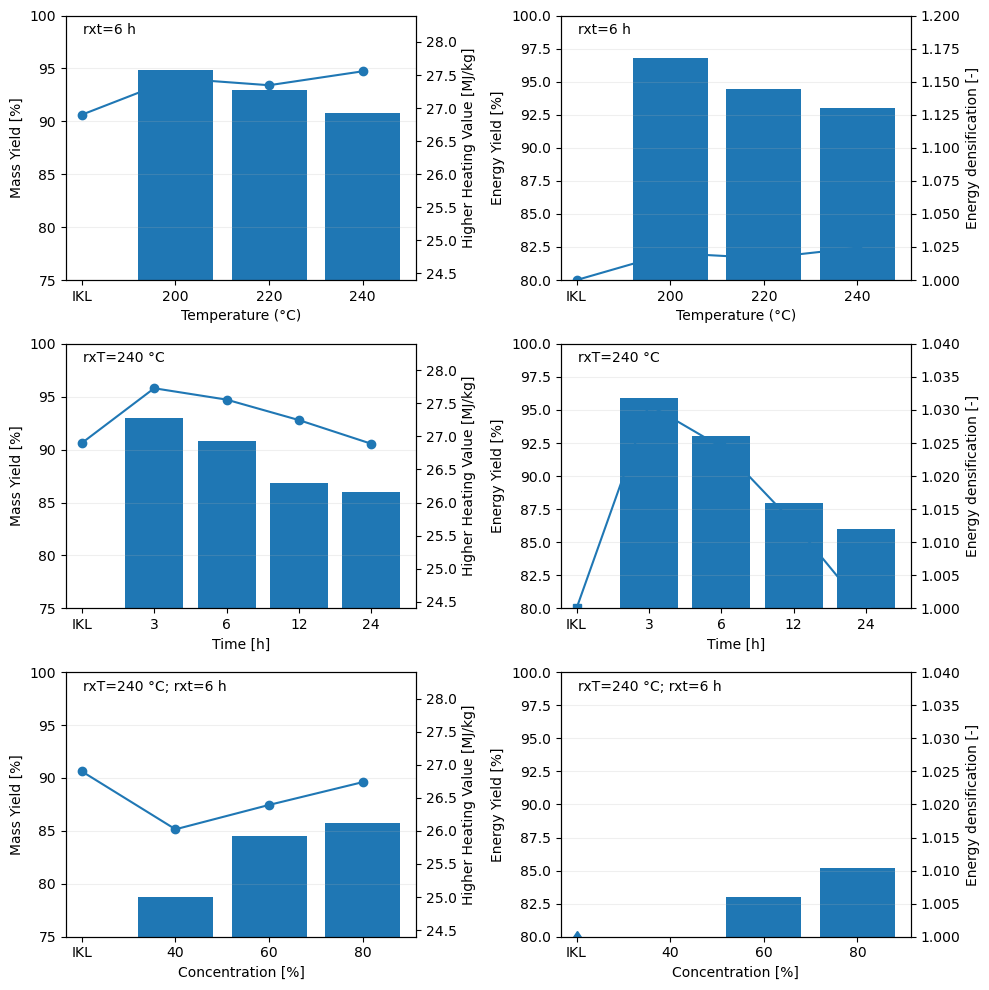

In [8]:
from matplotlib import pyplot as plt

def _recirc(x):
    try: d=json.loads(x) if isinstance(x,str) else {}
    except: d={}
    return d.get("recirculation_pct")

df["_recirc"] = df["extra"].apply(_recirc)

HHV_feed = 26.9
df["_EY_pct"] = (df["E_H"]/HHV_feed)*100
df["_EDF"] = df["HHV_biochar"]/HHV_feed

def series(kind):
    if kind=="T":
        base = pd.DataFrame({"label":["IKL"], "MY":[np.nan], "EY":[np.nan], "HHV":[HHV_feed], "EDF":[1.00]})
        s = df[(df["t"]==360) & df["_recirc"].isna()].sort_values("T")[["T","C_Y","_EY_pct","HHV_biochar","_EDF"]]
        s["label"] = s["T"].astype(int).astype(str)
    elif kind=="t":
        base = pd.DataFrame({"label":["IKL"], "MY":[np.nan], "EY":[np.nan], "HHV":[HHV_feed], "EDF":[1.00]})
        s = df[(df["T"]==240) & df["_recirc"].isna()].sort_values("t")[["t","C_Y","_EY_pct","HHV_biochar","_EDF"]]
        s["label"] = (s["t"]/60).astype(int).astype(str)
    else:
        base = pd.DataFrame({"label":["IKL"], "MY":[np.nan], "EY":[np.nan], "HHV":[HHV_feed], "EDF":[1.00]})
        s = df[(df["T"]==240) & (df["t"]==360) & df["_recirc"].notna()].sort_values("_recirc")[["_recirc","C_Y","_EY_pct","HHV_biochar","_EDF"]]
        s["label"] = s["_recirc"].astype(int).astype(str)
    s = s.rename(columns={"C_Y":"MY","_EY_pct":"EY","HHV_biochar":"HHV","_EDF":"EDF"})
    out = pd.concat([base, s[["label","MY","EY","HHV","EDF"]]], ignore_index=True)
    return out

def plot_panel(ax, df_panel, left_ylabel, right_ylabel, left_ylim, right_ylim, note, curve_col, marker):
    x = np.arange(len(df_panel))
    ax.bar(x, df_panel["MY" if "Mass" in left_ylabel else "EY"])
    ax.set_xticks(x); ax.set_xticklabels(df_panel["label"])
    ax.set_ylabel(left_ylabel); ax.set_ylim(*left_ylim); ax.grid(axis="y", alpha=0.2)
    ax2 = ax.twinx()
    ax2.plot(x, df_panel[curve_col], marker=marker)
    ax2.set_ylabel(right_ylabel); ax2.set_ylim(*right_ylim)
    if note: ax.text(0.05, 0.93, note, transform=ax.transAxes)

fig, axs = plt.subplots(3, 2, figsize=(10, 10))
axs = axs.ravel()

pT = series("T")
plot_panel(axs[0], pT, "Mass Yield [%]", "Higher Heating Value [MJ/kg]",
           (75,100), (24.4,28.4), "rxt=6 h", "HHV", "o")
axs[0].set_xlabel("Temperature (°C)")

plot_panel(axs[1], pT, "Energy Yield [%]", "Energy densification [-]",
           (80,100), (1.00,1.20), "rxt=6 h", "EDF", "o")
axs[1].set_xlabel("Temperature (°C)")

pt = series("t")
plot_panel(axs[2], pt, "Mass Yield [%]", "Higher Heating Value [MJ/kg]",
           (75,100), (24.4,28.4), "rxT=240 °C", "HHV", "o")
axs[2].set_xlabel("Time [h]")

plot_panel(axs[3], pt, "Energy Yield [%]", "Energy densification [-]",
           (80,100), (1.00,1.04), "rxT=240 °C", "EDF", "s")
axs[3].set_xlabel("Time [h]")

pc = series("c")
plot_panel(axs[4], pc, "Mass Yield [%]", "Higher Heating Value [MJ/kg]",
           (75,100), (24.4,28.4), "rxT=240 °C; rxt=6 h", "HHV", "o")
axs[4].set_xlabel("Concentration [%]")

plot_panel(axs[5], pc, "Energy Yield [%]", "Energy densification [-]",
           (80,100), (1.00,1.04), "rxT=240 °C; rxt=6 h", "EDF", "d")
axs[5].set_xlabel("Concentration [%]")

plt.tight_layout(); plt.show()


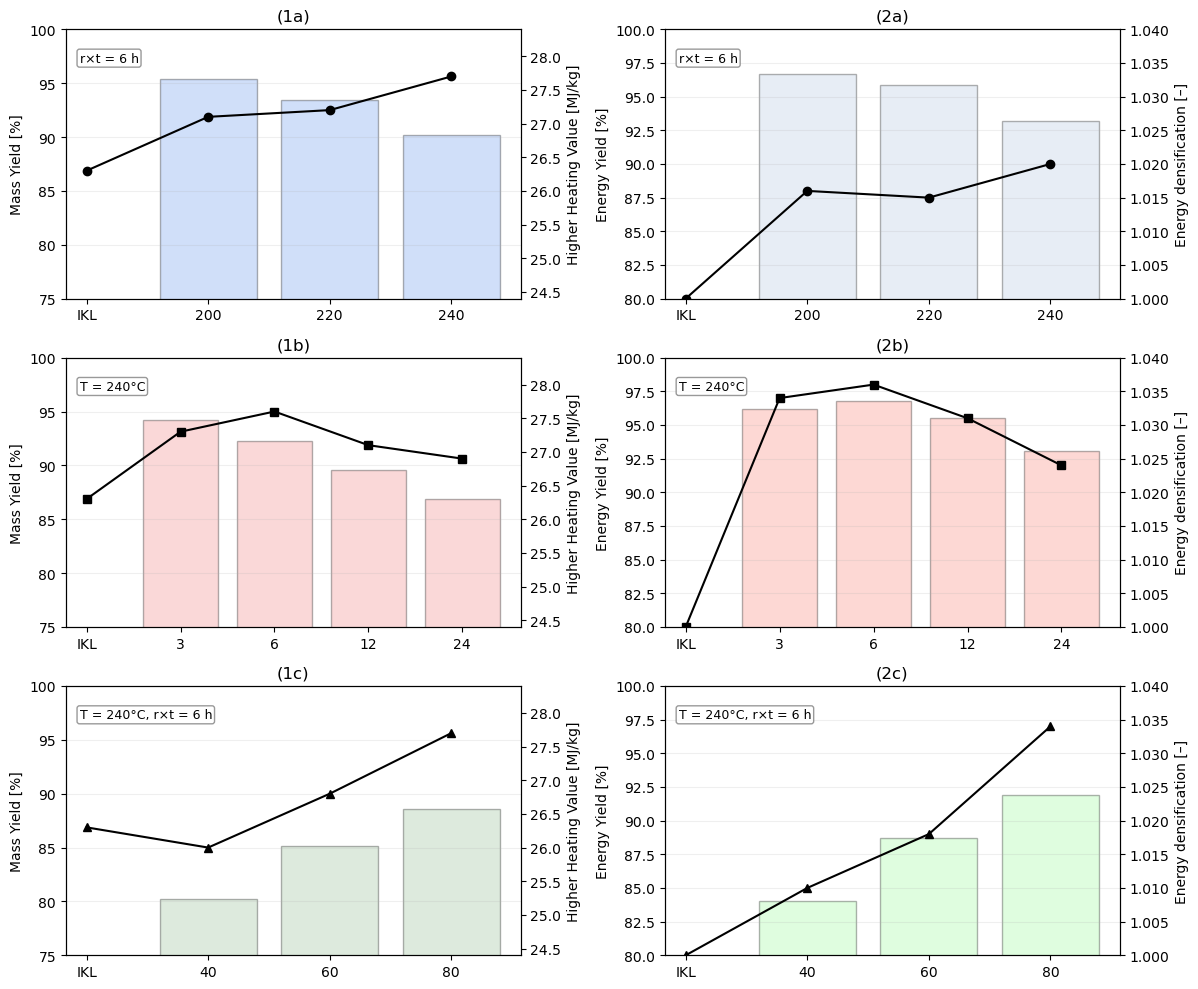

In [9]:
import numpy as np
import matplotlib.pyplot as plt

temp_labels = ["IKL", "200", "220", "240"]
temp_MY_bars = [np.nan, 95.4, 93.4, 90.2]
temp_HHV_curve = [26.3, 27.1, 27.2, 27.7]

temp_EY_bars = [np.nan, 96.7, 95.9, 93.2]
temp_EDF_curve = [1.0, 1.016, 1.015, 1.020]

time_labels = ["IKL", "3", "6", "12", "24"]
time_MY_bars = [np.nan, 94.2, 92.3, 89.6, 86.9]
time_HHV_curve = [26.3, 27.3, 27.6, 27.1, 26.9]

time_EY_bars = [np.nan, 96.2, 96.8, 95.5, 93.1]
time_EDF_curve = [1.0, 1.034, 1.036, 1.031, 1.024]

conc_labels = ["IKL", "40", "60", "80"]
conc_MY_bars = [np.nan, 80.2, 85.1, 88.6]
conc_HHV_curve = [26.3, 26.0, 26.8, 27.7]

conc_EY_bars = [np.nan, 84.0, 88.7, 91.9]
conc_EDF_curve = [1.0, 1.010, 1.018, 1.034]

def plot_dual_panel(ax, labels, bars, curve, bar_label, line_label, bar_color, marker, title, caption, bar_ylim, line_ylim):
    x = np.arange(len(labels))
    ax.bar(x[~np.isnan(bars)], np.array(bars)[~np.isnan(bars)], alpha=0.3, edgecolor='black', color=bar_color)
    ax.set_ylabel(bar_label)
    ax.set_ylim(*bar_ylim)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.text(0.03, 0.88, caption, transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8))
    ax.grid(True, axis='y', alpha=0.2)

    ax2 = ax.twinx()
    ax2.plot(x, curve, marker=marker, color="black")
    ax2.set_ylabel(line_label)
    ax2.set_ylim(*line_ylim)

fig, axs = plt.subplots(3, 2, figsize=(12, 10))
axs = axs.flatten()

plot_dual_panel(axs[0], temp_labels, temp_MY_bars, temp_HHV_curve,
                "Mass Yield [%]", "Higher Heating Value [MJ/kg]", 'cornflowerblue', 'o',
                "(1a)", "r×t = 6 h", (75, 100), (24.4, 28.4))

plot_dual_panel(axs[1], temp_labels, temp_EY_bars, temp_EDF_curve,
                "Energy Yield [%]", "Energy densification [–]", 'lightsteelblue', 'o',
                "(2a)", "r×t = 6 h", (80, 100), (1.00, 1.04))

plot_dual_panel(axs[2], time_labels, time_MY_bars, time_HHV_curve,
                "Mass Yield [%]", "Higher Heating Value [MJ/kg]", 'lightcoral', 's',
                "(1b)", "T = 240°C", (75, 100), (24.4, 28.4))

plot_dual_panel(axs[3], time_labels, time_EY_bars, time_EDF_curve,
                "Energy Yield [%]", "Energy densification [–]", 'salmon', 's',
                "(2b)", "T = 240°C", (80, 100), (1.00, 1.04))

plot_dual_panel(axs[4], conc_labels, conc_MY_bars, conc_HHV_curve,
                "Mass Yield [%]", "Higher Heating Value [MJ/kg]", 'darkseagreen', '^',
                "(1c)", "T = 240°C, r×t = 6 h", (75, 100), (24.4, 28.4))

plot_dual_panel(axs[5], conc_labels, conc_EY_bars, conc_EDF_curve,
                "Energy Yield [%]", "Energy densification [–]", 'palegreen', '^',
                "(2c)", "T = 240°C, r×t = 6 h", (80, 100), (1.00, 1.04))

plt.tight_layout()
plt.show()


E_H > 25.0 MJ/kg: 4 rows
E_B > 25.0 MJ/kg: 0 rows
B_Y outside [0,100]: 0 rows
C_Y outside [0,100]: 0 rows
C_B > 0.60 (fraction): 0 rows
C_H > 0.65 (fraction): 0 rows
HHV_input < 12 MJ/kg: 0 rows
H/C outside ~[0.8,1.9]: 0 rows
O/C outside ~[0.35,0.95]: 9 rows

-- E_H > 25.0 (showing 4 of 4) --
                       Feedstock proc    T    t  B_Y    C_Y  A_Y  G_Y  \
0  Industrial kraft lignin (IKL)  htc  200  360  NaN  94.86  NaN  NaN   
1  Industrial kraft lignin (IKL)  htc  220  360  NaN  92.93  NaN  NaN   
2  Industrial kraft lignin (IKL)  htc  240  360  NaN  90.79  NaN  NaN   
3  Industrial kraft lignin (IKL)  htc  240  180  NaN  93.01  NaN  NaN   

   HHV_biooil  HHV_biochar  E_B        E_H  C_B       C_H  HHV_input   O/C  \
0         NaN    27.449292  NaN  26.038398  NaN  0.623230      26.98  0.31   
1         NaN    27.345811  NaN  25.412462  NaN  0.611479      26.98  0.31   
2         NaN    27.556508  NaN  25.018554  NaN  0.598306      26.98  0.31   
3         NaN    27.728397  

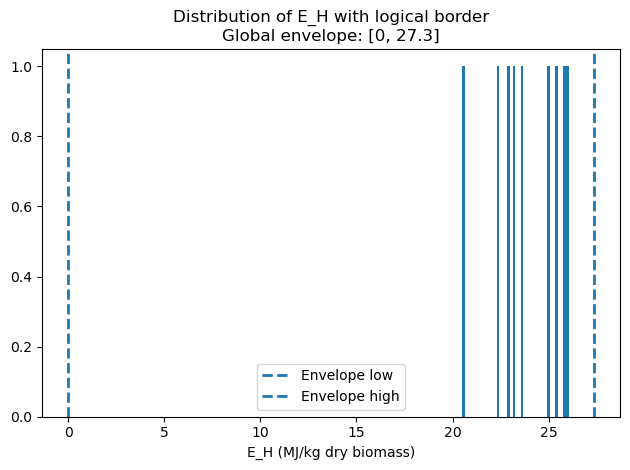

No data to plot for C_B.


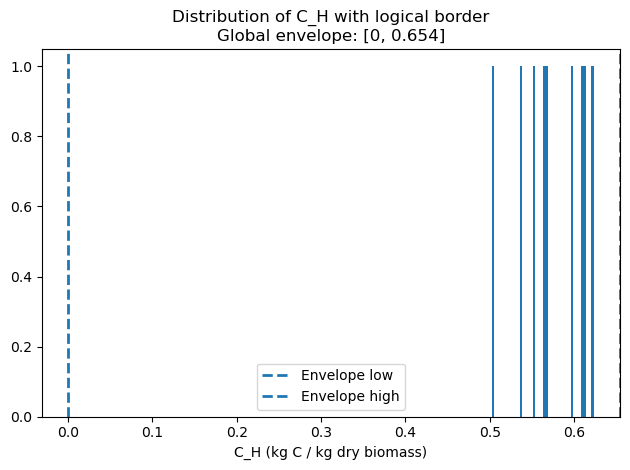

No data to plot for B_Y.


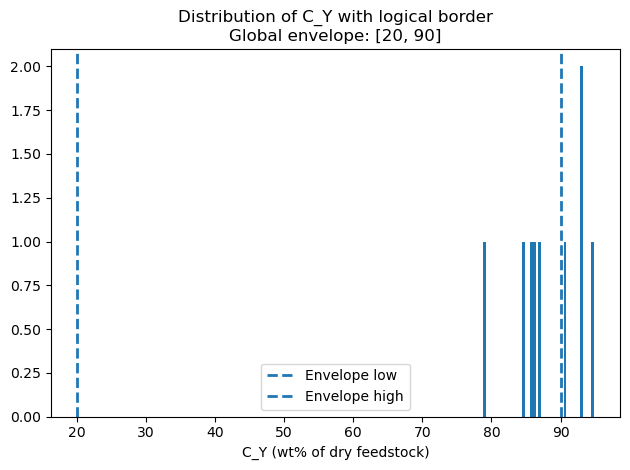

No data to plot for A_Y.
No data to plot for G_Y.


In [10]:
import importlib.util, pathlib, sys

mod_path = pathlib.Path("../../modules/qa_envelopes.py").resolve() 
spec = importlib.util.spec_from_file_location("qa_envelopes", str(mod_path))
qa_envelopes = importlib.util.module_from_spec(spec)
sys.modules["qa_envelopes"] = qa_envelopes
spec.loader.exec_module(qa_envelopes)

qa_envelopes.run_basic_qc(df)
qa_envelopes.plot_energy_carbon_envelopes(df)
qa_envelopes.plot_yield_envelopes(df)

In [11]:
import pandas as pd, numpy as np, json

def _first(s):
    try:
        v = s.dropna().astype(str).unique().tolist()
        return v[0] if v else "—"
    except Exception:
        return "—"

try:
    this_doi = PAPER_META.get("DOI")
except NameError:
    this_doi = None
if not this_doi and 'DOI' in df.columns:
    u = df['DOI'].dropna().astype(str).unique().tolist()
    this_doi = u[0] if u else None

mask = (df['DOI'].astype(str) == str(this_doi)) if (this_doi and 'DOI' in df.columns) else pd.Series(True, index=df.index)

print("DOI:", _first(df.loc[mask, 'DOI']) if 'DOI' in df.columns else '—')
print("Title:", _first(df.loc[mask, 'Paper_Title']) if 'Paper_Title' in df.columns else '—')
print("Provenance:", _first(df.loc[mask, 'Provenance']) if 'Provenance' in df.columns else '—')

def build_view(data, base_cols, comp_cols, sort_cols=("T","t")):
    cols_present = [c for c in base_cols if c in data.columns]
    view = data.loc[:, cols_present].copy()
    for c in comp_cols:
        view[c] = data[c] if c in data.columns else np.nan
    view = view[cols_present + comp_cols].dropna(how='all', subset=comp_cols)
    if all(c in view.columns for c in sort_cols):
        view = view.sort_values(list(sort_cols))
    return view

bo = build_view(df.loc[mask], [c for c in ('T','t') if c in df.columns],
                ['C_biooil','H_biooil','O_biooil','N_biooil','S_biooil','HHV_biooil'])
print("\nBio-oil composition & HHV (C/H/O/N/S, MJ/kg):")
print(bo.to_string(index=False) if not bo.empty else "(none)")

bc = build_view(df.loc[mask], [c for c in ('T','t') if c in df.columns],
                ['C_biochar','H_biochar','O_biochar','N_biochar','S_biochar','HHV_biochar'])
print("\nBiochar composition & HHV (C/H/O/N/S, MJ/kg):")
print(bc.to_string(index=False) if not bc.empty else "(none)")


DOI: 10.1016/j.fuel.2024.132389
Title: —
Provenance: Feed ultimate/ash & HHV from Table 4 (db); hydrochar ultimate (C/H/O/N/S) & HHV from Table 4 (db) operational details from Section 2.2 & 2.3; HHV char calculated where missing; 

Bio-oil composition & HHV (C/H/O/N/S, MJ/kg):
(none)

Biochar composition & HHV (C/H/O/N/S, MJ/kg):
  T    t  C_biochar  H_biochar  O_biochar  N_biochar  S_biochar  HHV_biochar
200  360       65.7       5.98       25.3       0.16       2.34    27.449292
220  360       65.8       5.71       25.8       0.18       2.22    27.345811
240  180       65.7       5.94       25.7       0.19       2.20    27.728397
240  360       65.9       5.22       26.1       0.20       2.17    27.556508
240  360       63.8       5.53       28.4       0.17       1.71    26.024259
240  360       63.6       5.62       28.5       0.20       1.69    26.392923
240  360       64.3       5.69       27.9       0.19       1.64    26.737618
240  720       65.4       5.45       26.9       0.18